This is a notebook I'm preparing while working through a [course](https://matteoacrossi.github.io/oqs-jupyterbook/) on simulating Open Quantum Systems using Qiskit. 

This would serve as a nice introduction to using Qiskit for someone who knows a lot about oqs and wants to learn 
- Basics of quantum circuit and gates
- Running jobs on a real quantum computer and hence basics of error mitigation that entails

*The error mitigation part in the actual course website is slightly outdated, so replaced with current **Qiskit Experiments** package*

In [76]:
# Importing relevant packages

import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace
import matplotlib.pyplot as plt
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Pauli

# %matplotlib inline

# Maximally Entangled $|\Psi^{-}\rangle$ state

Initial:  |00\rangle
After X(0):  |01\rangle
After X(1):  |11\rangle
After H(0): \frac{\sqrt{2}}{2} |10\rangle- \frac{\sqrt{2}}{2} |11\rangle
After CNOT(0, 1): - \frac{\sqrt{2}}{2} |01\rangle+\frac{\sqrt{2}}{2} |10\rangle


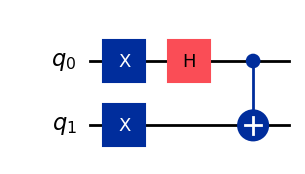

In [58]:
# Generating a maximally entangled Bell state

# # Setup
# You prepare two qubits (Q0 and Q1, say) 
# Initialise a circuit with two of them
q = QuantumRegister(2, name='q')
qc = QuantumCircuit(q)

# # Adding gates come next and we'll also make sure it works
# We will print out the statevector after each operation
state0 = Statevector.from_instruction(qc)
print(f"Initial: {state0.draw('latex_source')}")

# X on both Q0 and Q1
qc.x(q[0])
state1 = Statevector.from_instruction(qc)
print(f"After X(0): {state1.draw('latex_source')}")
qc.x(q[1])
state2 = Statevector.from_instruction(qc)
print(f"After X(1): {state2.draw('latex_source')}")


# H on Q0
qc.h(q[0])
state3 = Statevector.from_instruction(qc)
print(f"After H(0): {state3.draw('latex_source')}")

# CNOT on Q0 and Q1
qc.cx(q[0], q[1])
state4 = Statevector.from_instruction(qc)
print(f"After CNOT(0, 1): {state4.draw('latex_source')}")

# Draw the full progress
qc.draw(output='mpl') 

Since we'll need the maximally entangled $\Psi^{+}$ state multiple times in this analysis let's write a function which takes two qubits and a quantum circuit and returns a quantum circuit which produces a Bell state $\Psi^{+}$ between them

In [59]:
def psi_plus_bell_state(qc: QuantumCircuit, q0: int, q1: int) -> QuantumCircuit:
    '''
    Function for psi_plus_bell_state.
    Applies gates to quantum circuit to create a Psi-plus Bell state.
    
    Parameters
    ----------
    qc: QuantumCircuit 
        The quantum circuit object
    q0: int
        The control qubit index
    q1: int
        The target qubit index
        
    Returns
    -------
    QuantumCircuit
        The modified quantum circuit 
    '''    
    # X on Q1 --- |01> 
    qc.x(q1)
    
    # H on Q0 --- (|0> + |1>)|1>
    qc.h(q0)
    
    # CNOT on Q0 and Q1 --- |01> + |10>
    qc.cx(q0, q1)
    
    return qc

## Exercise: 2.1.1
Consider the following circuit


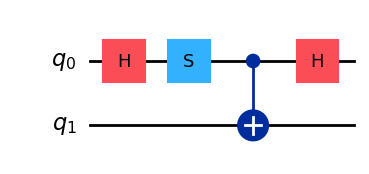

In [60]:
# Quantum register
q = QuantumRegister(2, name='q')

# Quantum circuit
entangled = QuantumCircuit(q)

# Entangled state
entangled.h(q[0])
entangled.s(q[0])
entangled.cx(q[0], q[1])
entangled.h(q[0])

# Draw circuit
entangled.draw(output='mpl')


- Write the resulting two-qubit quantum state $\rho_{q_0,q_1}=|\psi\rangle\langle\psi|$.



In [61]:
rho = DensityMatrix.from_instruction(qc)
print(f"Density Matrix")
rho.draw("Latex")

Density Matrix


<IPython.core.display.Latex object>

- Compute the partial trace to obtain the reduced density matrix $\rho_{q_0}$ of $q_0$.


In [62]:
ptrace = partial_trace(rho, [0])
print(r"Partial trace $\rho_{q0}$")
ptrace.draw("Latex")


Partial trace $\rho_{q0}$


<IPython.core.display.Latex object>

- Determine the Bloch vector x of $\rho_{q_0}$

In [63]:
# Calculating the components of Bloch vector 
r_x = ptrace.expectation_value(Pauli('X'))
r_y = ptrace.expectation_value(Pauli('Y'))
r_z = ptrace.expectation_value(Pauli('Z'))

print(f"Bloch vector x-component: {r_x.real}")
print(f"Full Bloch vector: ({r_x.real}, {r_y.real}, {r_z.real})")

Bloch vector x-component: 0.0
Full Bloch vector: (0.0, 0.0, 0.0)


- The Bloch vectors $\mathbf{x}$ and $\mathbf{y}$ of partial traces $\rho$ and $\sigma$ of a qubit serves as a measure of indistinguishability $0 \leq D[\rho,\sigma] \leq 1$, where $D[\rho,\sigma] = \frac 12 \, |\mathbf{x} - \mathbf{y}|$.

- Maximal Entanglement thus gives $D[\rho,\sigma] = 0$.

# Quantum Channels

- A quantum operation is a quantum channel.
- It can be an effect of measurement, which projects / maps the state of the system into a different state.
- But it's more vague than that. Any evolution or noise or measurement come under the umbrella of channels.
- If it doesn't map onto a physical state (pure or mixed) - it's not a channel but a map.

## Conditions for any map to be a channel
1. Bunch of criterion but one of the most useful is **completely positive**.  Quite a mouthful, but it essentially means, it needs to meet some essential criterion. 
2. Doing some mathematics / coding one finds the choi state by maximally entangling an auxiliary qubit to the qubit of interest and finds eigenvalues of the reduced density matrix obtained by tracing out one of the qubits. If they're non-negative you've got a completely positive channel.

# Exercise 2.2.1

Consider the following circuit implementing a channel on qubit $q_0$ (we assume $q_1$ to be initially in state $|0\rangle$)


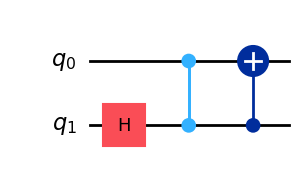

In [64]:
# Quantum register
q = QuantumRegister(2, name='q')

# Quantum circuit
channel = QuantumCircuit(q)
 
channel.h(q[1])
channel.cz(q[0], q[1])
channel.cx(q[1], q[0])

# Draw circuit
channel.draw(output='mpl')

- Calculate the outcoming state of $q_0$ for the following incoming states: 

    (a) $a |0\rangle + b |1\rangle$ with $|a|^2 + |b|^2 = 1$

In [65]:
# We'll start with a rather naive way of doing this and then make it a bit sophisticated

# Since we've used these gates in the qc in question, we won't be using the same
# However, we can initialise the state in this prep_circuit and then compose it with original channel
prep_channel = QuantumCircuit(2)

# Initialise q0 as (a |0> + b |1>) 
# Normalisation a and b can change as long as normalisation works
a = b = 1 / np.sqrt(2)
prep_channel.initialize([a, b], 0)

# We've not defined any gate yet, so the full state
full_state = Statevector.from_instruction(prep_channel)

print('Initial State')
full_state.draw("Latex")

Initial State


<IPython.core.display.Latex object>

**Comment**: This shows Qiskit convention: Writes the state backwards as $|q_{1}q_{0}\rangle$.

In [66]:
final_channel = prep_channel.compose(channel)

# Final state
print("Final State")
Statevector(final_channel).draw("Latex")

Final State


<IPython.core.display.Latex object>

(b) $p_1 |+ \rangle \langle +| + p_2 |- \rangle \langle - |$, where $p_1 + p_2 = 1$

In [67]:

# Lesson: You're better off using statevector.from_label and then density matrices all through
plus = Statevector.from_label('+')
minus = Statevector.from_label('-')
zero = Statevector.from_label('0')
one = Statevector.from_label('1')

p1 = p2 = 0.5
rho_q0 = p1 * DensityMatrix(plus) + p2 * DensityMatrix(minus)

rho_q1 = DensityMatrix(zero)

initial_rho = rho_q1.tensor(rho_q0)

# In case of density matrices you evolve the initial density matrix (that's what a quantum circuit does)
final_rho = initial_rho.evolve(channel)


print(f"Density Matrix")
final_rho.draw("Latex")
 

Density Matrix


<IPython.core.display.Latex object>

- Verify that the channel is completely positive using proposition 2 (consider a third ancillary qubit q2 maximally entangled with q0).



In [68]:
# Remember the function to generate |\psi^{+}\rangle Bell state. We're gonna use that here

# Quantum register
q = QuantumRegister(3, name='q')

channel = QuantumCircuit(q) # Quantum Circuit Initialised

channel = psi_plus_bell_state(channel, q[0], q[2])

# redefining the channel/circuit here - with three qubits now
print('Entangled state of Q0 and Q2')
display(Statevector(channel).draw("latex"))

channel.h(q[1])
channel.cz(q[0], q[1])
channel.cx(q[1], q[0])


# Final state
final_state = Statevector.from_instruction(channel)
final_rho = DensityMatrix(final_state)
print(f"3-Qubit Density Matrix")
display(final_rho.draw("latex"))



Entangled state of Q0 and Q2


<IPython.core.display.Latex object>

3-Qubit Density Matrix


<IPython.core.display.Latex object>

we can then trace out the qubit Q1 to find the choi state. One can then find the eigenvalues of this choi matrix to verify complete positivity. 

In [69]:
#Tracing out Q1 to find the choi state
choi = partial_trace(final_rho, [1])
print(f"Choi Matrix")
display(choi.draw("latex"))


Choi Matrix


<IPython.core.display.Latex object>

Verifying Complete Positivity

In [70]:
eigenvalues, eigenvec = np.linalg.eigh(choi.data)
print("Eigenvalues of the Choi matrix:", np.round(np.real(eigenvalues), 3))

Eigenvalues of the Choi matrix: [0.  0.  0.5 0.5]


- The Kraus operator can be built purely from the Choi matrix. 
- Its eigenvalue tells us how likely a quantum trajectory is to take place (its probability or weighting). 
- So, Kraus operator is $\sqrt{\lambda_i}\text{Choi}_{ij}$, where $\text{Choi}_{ij}$ are the eigenvectors corresponding to positive eigenvalues.


- Determine the Kraus representation of the channel.



Sanity Checked: Sum of K_i^dagger K_i equals Identity.

Kraus Operator K_0:
 [[0.   +0.j 0.707+0.j]
 [0.707+0.j 0.   +0.j]]

Kraus Operator K_1:
 [[-0.707+0.j  0.   +0.j]
 [ 0.   +0.j  0.707+0.j]]


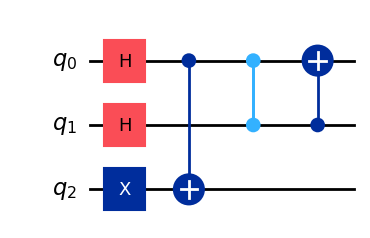

In [71]:
mask = eigenvalues > 0

eigenvec = eigenvec[:, mask]
eigenvalues = eigenvalues[mask]

kraus = []
prod = np.zeros((2, 2), dtype=complex)

for k in range(len(eigenvalues)):
    pos_eigen_choi = eigenvec[:, k]
    init_kraus = pos_eigen_choi.reshape((2, 2), order = 'F') # F for fortran. python doesn't automatically reshape it the way we want
    
    
    #Kraus Operator 
    # Issue with qiskit - need to multiply by a scaling factor = dimension
    d = len(eigenvalues)
    init_kraus = np.multiply(np.sqrt(eigenvalues[k] * d), init_kraus)
    kraus.append(init_kraus)
    
    prod += init_kraus.conjugate().T @ init_kraus

if np.allclose(prod, np.eye(2)):
    print('\nSanity Checked: Sum of K_i^dagger K_i equals Identity.')
    for idx, k_op in enumerate(kraus):
        print(f'\nKraus Operator K_{idx}:\n', np.round(k_op, 3))
else:
    print('\nSanity Check Failed.')


channel.draw(output='mpl')
# plt.show()


# Error Mitigation

This section caught me off gaurd a little bit. The error mitigation package used here is a bit obsolete. However, I realised later that the same things can be done using **Qiskit Measurements** package. That's what we'll be using in this section and henceforth. Mind you, this is just enough to do what I do here, there's an entire research topic called error mitigation and correction which I want to look at in future. 


### Some Advice
1. Errors compound with circuit depth - more gates - longer run - more errors.
2. Not all gates are realisable.
	- complicated multi-qubit gates get converted into swaps (each having 3 CNOTs).
	- We avoid CNOTs like hell coz it has 10 times the error of a phase flip.
	- Only multiqubit operation available in CNOT - try to define them ONLY between **connected qubits**.
	- **Two qubits are connected in a given device if there is a basis CNOT between them.**

3. OQS specific advice:
	- system qubit - use low error qubits.
	- Auxiliary or environment qubits can be designated noisier ones



# Readout Error Mitigation
Measurement of any qubit gives rise to readout errors. The readout error mitigator is used to obtain realistic distribution of outputs. 

1. We can calculate how likely we're to get an output y given that output should have been x.
2. This would correspond to matrix element $A_{yx}$ of the $2^{n} \times 2^{n}$ assignment matrix for n qubits.
3. Using this one calculates the mitigation matrix (not sure how!)

Two types of readout mitigator:
1. Assuming readout errors are local (one qubit error doesn't affect the others).
	- Assignment matrix is tensor product of n $2 \times 2$ matrices.
	- One needs to store each individual matrix.
  
2. Different case, where noise is correlated, full $2^{n} \times 2^{n}$ matrix is required.
   - Becomes intractable for more qubits.
   - Note: OQS course uses correlated noise, since it's dealing with smaller systems.


***Qiskit provides error mitigation tools from where we'll look only into correlated error mitigation - because our system sizes are fairly small.***

To begin, we would need access to a real quantum computer. Turns out the ***AerSimulator*** package offers quantum simulators which introduce realistic noise and produces results an actual quantum computer will introduce.

*This is just a dummy to implement error mitigation for now. I will run things on an actual quantum computer when I do actual simulations.*

In [72]:
from qiskit_experiments.library import LocalReadoutError, CorrelatedReadoutError
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakePerth 


from qiskit.visualization import plot_histogram

# So here, the backend runs on a fake simulator called FakePerth
backend = AerSimulator.from_backend(FakePerth())



--- Calibration Circuit 0 ---


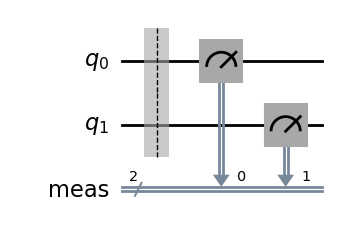


--- Calibration Circuit 1 ---


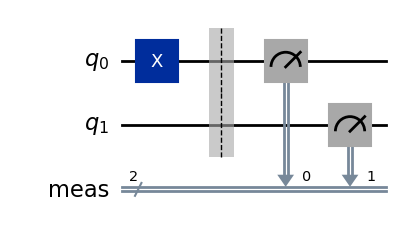


--- Calibration Circuit 2 ---


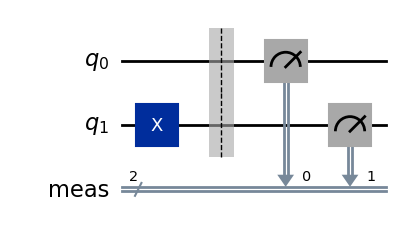


--- Calibration Circuit 3 ---


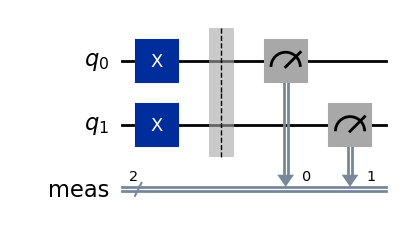

In [73]:

backend = AerSimulator.from_backend(FakePerth())

physical_qubits = [0, 2]
 
exp = CorrelatedReadoutError(physical_qubits)

for i, circ in enumerate(exp.circuits()):
    print(f"\n--- Calibration Circuit {i} ---")
    display(circ.draw(output='mpl'))
    


The tricky bit here is that, unlike legacy package ***ignis***, the error mitigation model and hence calibration cicuit generation is hardware agnostic so, just needs to know which which qubits need correcting.

It generates a compact, 2-wire circuit when we tell the simulator we want to measure noise levels on the two specific qubits of five in FakePerth.

**Funny part**: This generation of calibration matrix is no black magic. You take two qubits of interest, perform these $\sigma_{x}$ measurements alternatively, or on both or on none to obtain all the elements of the two qubit calibration matrix. 

***Now running these circuits on the backend gives us the experimental data, we can create mitigator out of - essentially to neutralise the noise.***

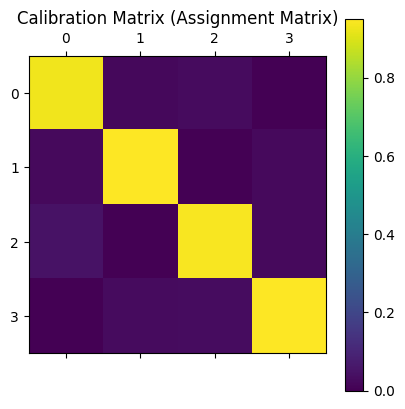

In [74]:
exp_data = exp.run(backend)
mitigator = exp_data.analysis_results("Correlated Readout Mitigator", dataframe=True).iloc[0].value 


cal_matrix = mitigator.assignment_matrix()
plt.matshow(cal_matrix, cmap='viridis')
plt.title("Calibration Matrix (Assignment Matrix)")
plt.colorbar()
plt.show()

See how these off-diagonal terms have brightened up. That sets a standard for the computation we do and well error mitigate using this matrix. 

- Next, I've got 5 qubits in FakePerth and then perform measurements on two qubits (classical bits represent measurement).
- Measurement is done on a two qubit bell state between 0, 2 qubits (ones we generated calibration matrix for).

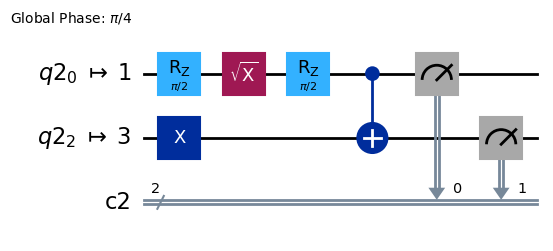

In [78]:
# 1. Setup
q = QuantumRegister(5) 
c = ClassicalRegister(2) 
bell = QuantumCircuit(q) 

bell = psi_plus_bell_state(bell, q[0], q[2])

meas = QuantumCircuit(q, c)
meas.measure(q[0], c[0])
meas.measure(q[2], c[1])

qc = bell.compose(meas)

# Added transpilation step to translate 'h' to the backend's native gates
# job = backend.run(qc, shots = 1000) # running straightaway would cause problems coz all gates don't exist
qc_transpiled = transpile(qc, backend)

qc_transpiled.draw(output='mpl')

- The transpiled circuit shows how the high-level gates are broken down into the native gates

*See how complicated it is. That's a simple quantum algorithm at play to break these circuits down into implementable ones.*

- Next the quantum circuit is run multiple times to get a good average. 
- The counts can then be used as a baseline to apply the mitigation (assignment) matrix on.
- Quasi-probability you calculate here is basically the inverse of the assignment matrix. Quasi- coz it can return negative probability values when applied on the raw counts.
- In order to map on a physical system, `.nearest_probability_distribution()` function uses a Maximum Likelihood algorithm

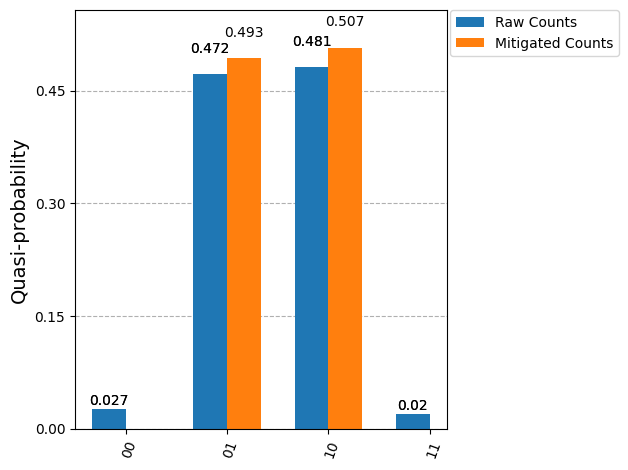

In [ ]:
num_runs = 1000 # Ideally high
job = backend.run(qc_transpiled, shots = num_runs)

counts = job.result().get_counts()

# Applying the inverse matrix to the raw counts
mitigated_quasi_probs = mitigator.quasi_probabilities(counts)

# Mapping quasi-probs to the nearest valid physical probabilities
mitigated_probs = mitigated_quasi_probs.nearest_probability_distribution()

# Convert probabilities back to count-like values for plotting
mitigated_counts = {f"{int(state):02b}": prob * num_runs for state, prob in mitigated_probs.items()}

plot_histogram([counts, mitigated_counts], legend=['Raw Counts', 'Mitigated Counts'])